In [1]:
# ============================================================
# CELL 1 — IMPORT LIBRARIES & LOAD FINAL DATASET
# ============================================================

import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

import warnings
warnings.filterwarnings("ignore")


# ============================================================
# LOAD DATASET
# ============================================================

file_path = "data/datasetLinkedInprocessed.csv"

df = pd.read_csv(file_path)


# ============================================================
# DROP DATA SOURCE
# ============================================================

if "data_source" in df.columns:
    df = df.drop(columns=["data_source"])


# ============================================================
# BASIC INFORMATION
# ============================================================

print("=" * 60)
print("FINAL DATASET LOADED")
print("=" * 60)

print("\nDataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nData types:")
print(df.dtypes)

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


FINAL DATASET LOADED

Dataset shape: (10000, 3)

Columns:
['id', 'description', 'high_performing']

First 5 rows:


,id,description,high_performing
0,SYNTH_TEXT_01773,The successful candidate will contribute to me...,0
1,SYNTH_TEXT_06212,The role provides an opportunity to contribute...,1
2,4443526653,"POSITION IS 100% ONSITE DAILY IN NORCO, CA\n\n...",1
3,SYNTH_TEXT_02544,The successful candidate will contribute to me...,0
4,SYNTH_TEXT_00241,This role combines technical and professional ...,0



Data types:
id                   str
description          str
high_performing    int64
dtype: object


In [2]:
# ============================================================
# CELL 2 — DATA QUALITY CHECK
# ============================================================

print("=" * 60)
print("DATA QUALITY CHECK")
print("=" * 60)

print("\nMissing values:")
display(df.isnull().sum().to_frame("missing_values"))

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nDuplicate IDs:")
print(df["id"].duplicated().sum())

print("\nTarget distribution:")
display(
    df["high_performing"]
    .value_counts()
    .sort_index()
    .to_frame("count")
)

DATA QUALITY CHECK

Missing values:


,missing_values
id,0
description,0
high_performing,0



Duplicate rows:
0

Duplicate IDs:
0

Target distribution:


,count
high_performing,
0,4997
1,5003


In [3]:
# ============================================================
# CELL 3 — TEXT FEATURE ENGINEERING
# ============================================================

df["description"] = (
    df["description"]
    .fillna("")
    .astype(str)
)

df["description_length"] = (
    df["description"].str.len()
)

df["description_word_count"] = (
    df["description"]
    .str.split()
    .str.len()
)

df["description_sentence_count"] = (
    df["description"]
    .str.count(r"[.!?]")
)

print("=" * 60)
print("TEXT FEATURES CREATED")
print("=" * 60)

display(
    df[
        [
            "description_length",
            "description_word_count",
            "description_sentence_count"
        ]
    ].describe()
)

TEXT FEATURES CREATED


,description_length,description_word_count,description_sentence_count
count,10000.000000,10000.000000,10000.000000
mean,2690.277200,378.153200,19.653600
std,2395.234486,336.199539,17.059904
min,443.000000,57.000000,0.000000
25%,1122.000000,158.000000,9.000000
50%,1485.000000,211.000000,12.000000
75%,4165.000000,577.000000,25.000000
max,17998.000000,2638.000000,426.000000


HIGH-PERFORMING JOB LISTINGS

0 = Low-performing
1 = High-performing


,count
high_performing,
0,4997
1,5003


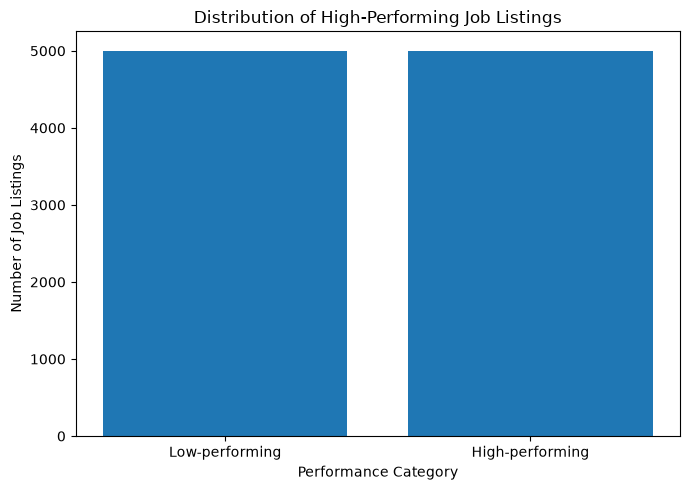

In [4]:
# ============================================================
# CELL 4 — HIGH-PERFORMING DISTRIBUTION
# ============================================================

target_counts = (
    df["high_performing"]
    .value_counts()
    .sort_index()
)

print("=" * 60)
print("HIGH-PERFORMING JOB LISTINGS")
print("=" * 60)

print("\n0 = Low-performing")
print("1 = High-performing")

display(
    target_counts.to_frame("count")
)


plt.figure(figsize=(7, 5))

plt.bar(
    ["Low-performing", "High-performing"],
    [
        target_counts.get(0, 0),
        target_counts.get(1, 0)
    ]
)

plt.xlabel("Performance Category")
plt.ylabel("Number of Job Listings")
plt.title("Distribution of High-Performing Job Listings")

plt.tight_layout()
plt.show()

In [5]:
# ============================================================
# CELL 5 — TEXT FEATURES VS PERFORMANCE
# ============================================================

text_summary = (
    df.groupby("high_performing")[
        [
            "description_length",
            "description_word_count",
            "description_sentence_count"
        ]
    ]
    .mean()
)

text_summary.index = [
    "Low-performing",
    "High-performing"
]

print("=" * 60)
print("TEXT FEATURES BY PERFORMANCE")
print("=" * 60)

display(text_summary)

TEXT FEATURES BY PERFORMANCE


,description_length,description_word_count,description_sentence_count
Low-performing,2711.690614,381.302782,19.804082
High-performing,2668.889466,375.007396,19.503298


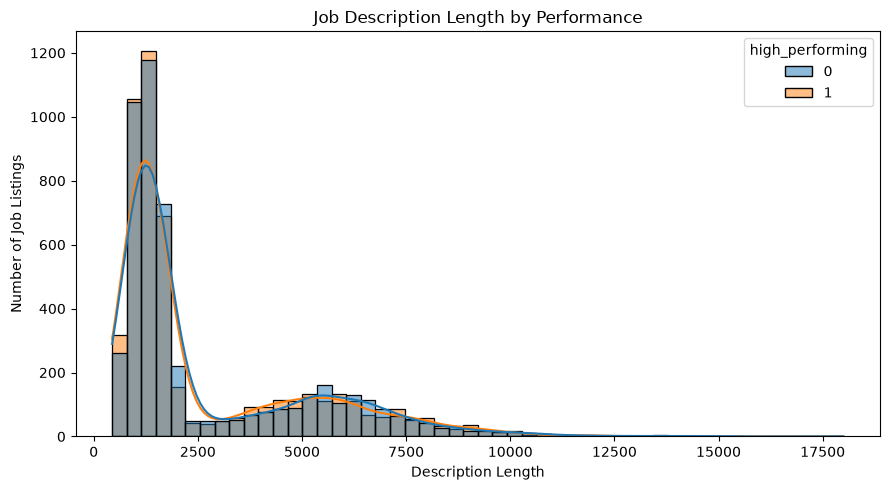

In [6]:
# ============================================================
# CELL 6 — DESCRIPTION LENGTH DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="description_length",
    hue="high_performing",
    bins=50,
    kde=True
)

plt.xlabel("Description Length")
plt.ylabel("Number of Job Listings")
plt.title("Job Description Length by Performance")

plt.tight_layout()
plt.show()

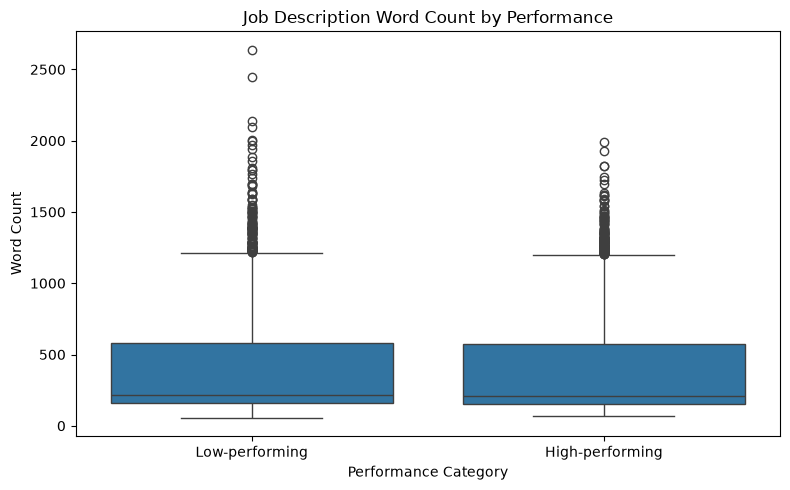

In [7]:
# ============================================================
# CELL 7 — WORD COUNT BY PERFORMANCE
# ============================================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="high_performing",
    y="description_word_count"
)

plt.xlabel("Performance Category")
plt.ylabel("Word Count")
plt.title("Job Description Word Count by Performance")

plt.xticks(
    [0, 1],
    ["Low-performing", "High-performing"]
)

plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# CELL 8 — PREPARE DATA FOR TF-IDF
# ============================================================

text_df = df[
    ["description", "high_performing"]
].copy()

text_df["description"] = (
    text_df["description"]
    .fillna("")
    .astype(str)
)

text_df["high_performing"] = (
    text_df["high_performing"]
    .astype(int)
)

X = text_df["description"]
y = text_df["high_performing"]

print("Total records:", len(text_df))
print("Features:", X.name)
print("Target:", y.name)

Total records: 10000
Features: description
Target: high_performing


In [9]:
# ============================================================
# CELL 9 — TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training records: 8000
Testing records: 2000

Training target distribution:
high_performing
1    4002
0    3998
Name: count, dtype: int64

Testing target distribution:
high_performing
1    1001
0     999
Name: count, dtype: int64


In [10]:
# ============================================================
# CELL 10 — TF-IDF + LOGISTIC REGRESSION
# ============================================================

tfidf_model = Pipeline([
    
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            strip_accents="unicode",
            ngram_range=(1, 2),
            min_df=3,
            max_df=0.95,
            max_features=20000,
            sublinear_tf=True
        )
    ),
    
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            C=1.0,
            random_state=42
        )
    )
])


# Train model
tfidf_model.fit(
    X_train,
    y_train
)


# Predictions
y_pred = tfidf_model.predict(X_test)

y_prob = (
    tfidf_model
    .predict_proba(X_test)[:, 1]
)

print("TF-IDF + Logistic Regression model trained successfully.")

TF-IDF + Logistic Regression model trained successfully.


In [11]:
# ============================================================
# CELL 11 — MODEL EVALUATION
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)


print("=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)

print(f"\nAccuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")


print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Low-performing",
            "High-performing"
        ],
        zero_division=0
    )
)

MODEL PERFORMANCE

Accuracy : 0.8170
Precision: 0.8015
Recall   : 0.8432
F1 Score : 0.8218
ROC-AUC  : 0.8918

Classification Report:
                 precision    recall  f1-score   support

 Low-performing       0.83      0.79      0.81       999
High-performing       0.80      0.84      0.82      1001

       accuracy                           0.82      2000
      macro avg       0.82      0.82      0.82      2000
   weighted avg       0.82      0.82      0.82      2000



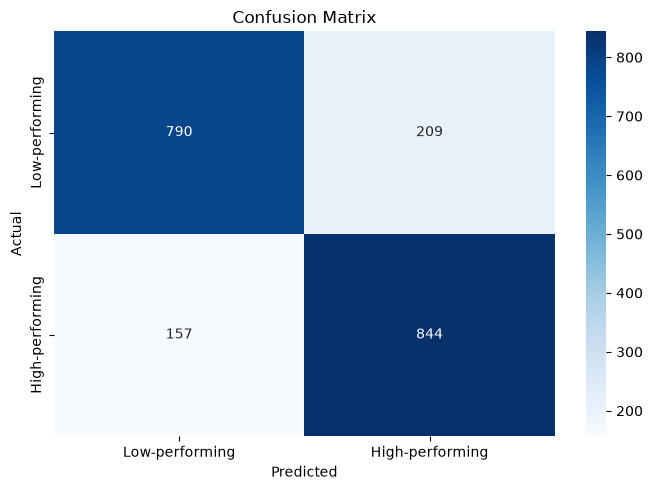

In [12]:
# ============================================================
# CELL 12 — CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Low-performing",
        "High-performing"
    ],
    yticklabels=[
        "Low-performing",
        "High-performing"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

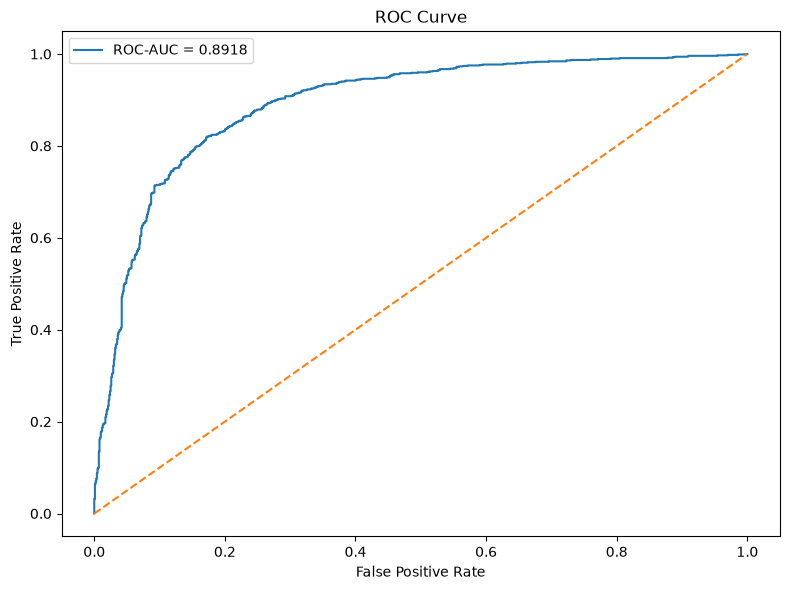

In [13]:
# ============================================================
# CELL 13 — ROC CURVE
# ============================================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

roc_auc_value = auc(
    fpr,
    tpr
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc_value:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# CELL 14 — IMPORTANT TF-IDF TERMS
# ============================================================

tfidf = tfidf_model.named_steps["tfidf"]

classifier = (
    tfidf_model
    .named_steps["classifier"]
)

feature_names = np.array(
    tfidf.get_feature_names_out()
)

coefficients = classifier.coef_[0]

term_importance = pd.DataFrame({
    "term": feature_names,
    "coefficient": coefficients
})


high_terms = (
    term_importance
    .sort_values(
        "coefficient",
        ascending=False
    )
    .head(30)
)

low_terms = (
    term_importance
    .sort_values(
        "coefficient",
        ascending=True
    )
    .head(30)
)


print("=" * 60)
print("TF-IDF TERM IMPORTANCE")
print("=" * 60)

print("\nTerms associated with high-performing listings:")
display(high_terms)

print("\nTerms associated with low-performing listings:")
display(low_terms)

TF-IDF TERM IMPORTANCE

Terms associated with high-performing listings:


,term,coefficient
5162,data,2.566113
8364,healthcare,1.956479
5580,design,1.890498
3487,business,1.838970
717,ai,1.747191
4136,clinical,1.358538
909,american,1.345917
14392,real,1.324391
687,agent,1.289732
5166,data analyst,1.287214



Terms associated with low-performing listings:


,term,coefficient
13925,project,-4.508804
4715,construction,-3.092513
636,affirm,-2.511695
888,amazon,-1.969842
10244,leidos,-1.786333
6930,execution,-1.738354
19982,your team,-1.709927
16335,stripe,-1.657926
3778,capital one,-1.649014
13938,project manager,-1.632241
